# Deep Embedded Clustering (DEC) untuk Citra
## Pipeline Lengkap: Preprocessing → Autoencoder → K-Means → DEC → Evaluasi
---

## Cell 1 — Install & Import Library

In [30]:
# ============================================================
# CELL 1: INSTALL & IMPORT SEMUA LIBRARY YANG DIBUTUHKAN
# ============================================================

# Install tambahan jika belum ada
# !pip install scikit-learn matplotlib seaborn tqdm -q

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import shutil
import json
import time

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Seed untuk reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version :', tf.__version__)
print('GPU tersedia        :', tf.config.list_physical_devices('GPU'))
print('Library siap digunakan.')

TensorFlow version : 2.20.0
GPU tersedia        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Library siap digunakan.


## Cell 2 — Konfigurasi Global

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!cp -r /content/drive/MyDrive/image_dataset /content/

In [ ]:
import os

dataset_path = "/content/image_dataset"

print(os.listdir(dataset_path)[:10])  # cek isi folder

In [ ]:
import os

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')

all_files = [
    f for f in os.listdir("/content/image_dataset")
    if f.lower().endswith(valid_ext)
]

print("Jumlah gambar:", len(all_files))

In [38]:
# ============================================================
# CELL 2: KONFIGURASI GLOBAL
# Ubah nilai di sini sesuai kebutuhan
# ============================================================

CONFIG = {
    # --- PATH ---
    'dataset_path'     : '/content/image_dataset',          # folder hasil ekstraksi zip
    'output_root'      : '/content/hasil_cluster',    # root penyimpanan hasil

    # --- PREPROCESSING ---
    'img_size'         : 224,          # ukuran gambar (H x W)
    'batch_size_load'  : 32,           # batch saat loading (hemat RAM)

    # --- AUTOENCODER ---
    'latent_dim'       : 64,           # dimensi latent space
    'ae_epochs'        : 100,          # maksimum epoch autoencoder
    'ae_batch_size'    : 32,
    'ae_lr'            : 1e-3,

    # --- CLUSTERING ---
    'n_clusters'       : 5,           # jumlah cluster

    # --- DEC ---
    'dec_epochs'       : 100,          # maksimum iterasi DEC
    'dec_batch_size'   : 256,
    'dec_lr'           : 1e-4,
    'update_interval'  : 5,            # update centroid setiap N batch
    'tol'              : 0.001,        # stopping criterion (delta label < tol)

    # --- VISUALISASI ---
    'tsne_perplexity'  : 30,
    'n_sample_vis'     : 8,            # jumlah contoh citra per cluster
}

# Buat folder output
os.makedirs(CONFIG['output_root'], exist_ok=True)
os.makedirs(os.path.join(CONFIG['output_root'], 'grafik'), exist_ok=True)
os.makedirs(os.path.join(CONFIG['output_root'], 'model'), exist_ok=True)

print('Konfigurasi:')
for k, v in CONFIG.items():
    print(f'  {k:20s}: {v}')

Konfigurasi:
  dataset_path        : /content/image_dataset
  output_root         : /content/hasil_cluster
  img_size            : 224
  batch_size_load     : 32
  latent_dim          : 64
  ae_epochs           : 100
  ae_batch_size       : 32
  ae_lr               : 0.001
  n_clusters          : 5
  dec_epochs          : 100
  dec_batch_size      : 256
  dec_lr              : 0.0001
  update_interval     : 5
  tol                 : 0.001
  tsne_perplexity     : 30
  n_sample_vis        : 8


## Cell 3 — Fungsi Preprocessing (sama seperti sebelumnya)

In [ ]:
# ============================================================
# CELL 3: FUNGSI PREPROCESSING CITRA (CLUSTERING OPTIMIZED)
# (Resize → Denoising → CLAHE → Sharpen → Normalize)
# ============================================================

import cv2
import numpy as np

def preprocess_image_advanced(image_path, img_size=224):
    """
    Preprocessing optimal untuk clustering citra:
    1. Resize awal
    2. Denoising ringan
    3. CLAHE (peningkatan kontras)
    4. Sharpen ringan
    5. Normalize [0,1]

    CATATAN:
    GrabCut & AutoCrop DIHAPUS
    karena sering memperburuk clustering.
    """

    try:
        # ====================================================
        # Load image
        # ====================================================
        img = cv2.imread(image_path)

        if img is None:
            raise ValueError(
                f'Gambar tidak dapat dibaca: {image_path}'
            )

        # BGR → RGB
        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        # ====================================================
        # 1. Resize awal
        # ====================================================
        img = cv2.resize(
            img,
            (img_size, img_size),
            interpolation=cv2.INTER_AREA
        )

        # ====================================================
        # 2. Denoising ringan
        # ====================================================
        img = cv2.GaussianBlur(
            img,
            (3, 3),
            0
        )

        # ====================================================
        # 3. CLAHE pada channel L
        # ====================================================
        lab = cv2.cvtColor(
            img,
            cv2.COLOR_RGB2LAB
        )

        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

        l = clahe.apply(l)

        lab = cv2.merge((l, a, b))

        img = cv2.cvtColor(
            lab,
            cv2.COLOR_LAB2RGB
        )

        # ====================================================
        # 4. Sharpen ringan
        # ====================================================
        kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ])

        img = cv2.filter2D(
            img,
            -1,
            kernel
        )

        # ====================================================
        # 5. Normalize [0,1]
        # ====================================================
        img = img.astype(
            np.float32
        ) / 255.0

        return img

    except Exception as e:

        print(
            f'[WARNING] Gagal proses {image_path}: {e}'
        )

        return None


print("Fungsi preprocessing clustering siap.")

## Cell 4 — Load Dataset Hasil Preprocessing

In [ ]:
# ============================================================
# CELL 4: LOAD DATASET HASIL PREPROCESSING
# ============================================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Path dataset langsung dari Google Drive / folder
CONFIG['dataset_path'] = "/content/image_dataset"
# atau ganti sesuai folder Anda

print("Dataset path:", CONFIG['dataset_path'])

def load_dataset_preprocessed(dataset_path, img_size=224):

    valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    all_paths = []

    for root, _, files in os.walk(dataset_path):
        for f in files:
            if f.lower().endswith(valid_ext):
                all_paths.append(os.path.join(root, f))

    all_paths.sort()
    print(f'Total file ditemukan: {len(all_paths)}')

    images, paths_ok = [], []

    for path in tqdm(all_paths, desc='Preprocessing & Loading'):
        img = preprocess_image_advanced(path, img_size)

        if img is not None:
            images.append(img)
            paths_ok.append(path)

    images = np.array(images, dtype='float32')

    print(f'\nBerhasil dimuat : {len(images)} gambar')
    print(f'Shape dataset   : {images.shape}')

    if len(images) > 0:
        print(f'Min/Max pixel   : {images.min():.4f} / {images.max():.4f}')

    return images, paths_ok


# ---- Eksekusi ----
images, image_paths = load_dataset_preprocessed(
    CONFIG['dataset_path'],
    CONFIG['img_size']
)

# Validasi dataset
if len(images) == 0:
    print("\n[ERROR] Tidak ada gambar ditemukan.")
else:

    os.makedirs(CONFIG['output_root'], exist_ok=True)
    os.makedirs(os.path.join(CONFIG['output_root'], 'grafik'), exist_ok=True)

    # Simpan image path
    with open(os.path.join(CONFIG['output_root'], 'image_paths.json'), 'w') as f:
        json.dump(image_paths, f, indent=2)

    # Preview
    n_preview = min(8, len(images))

    fig, axes = plt.subplots(2, 4, figsize=(16, 5))
    axes = axes.flatten()

    for i in range(n_preview):
        axes[i].imshow(images[i])
        axes[i].set_title(f'Sample {i+1}', fontsize=8)
        axes[i].axis('off')

    plt.suptitle(
        'Preview Dataset Setelah Preprocessing',
        fontsize=13,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            CONFIG['output_root'],
            'grafik',
            '00_preview_dataset.png'
        ),
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print("Preview dataset disimpan.")

## Cell 5 — Arsitektur CNN Autoencoder

In [39]:
# ============================================================
# CELL 5: CNN AUTOENCODER
# Encoder: Conv → MaxPool (bertahap)
# Bottleneck: Flatten → Dense (latent)
# Decoder: Dense → Reshape → UpSampling → Conv
# ============================================================

def build_autoencoder(input_shape=(224, 224, 3), latent_dim=64):
    """
    CNN Autoencoder dengan bottleneck latent_dim dimensi.
    Mengembalikan: autoencoder, encoder, decoder
    """
    H, W, C = input_shape

    # ---- ENCODER ----
    enc_input = layers.Input(shape=input_shape, name='encoder_input')

    x = layers.Conv2D(32, 3, activation='relu', padding='same', name='enc_conv1')(enc_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, padding='same')(x)         # 224->112

    x = layers.Conv2D(64, 3, activation='relu', padding='same', name='enc_conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, padding='same')(x)         # 112->56

    x = layers.Conv2D(128, 3, activation='relu', padding='same', name='enc_conv3')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, padding='same')(x)         # 56->28

    x = layers.Conv2D(256, 3, activation='relu', padding='same', name='enc_conv4')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, padding='same')(x)         # 28->14

    shape_before_flatten = K.int_shape(x)[1:]             # simpan shape untuk decoder

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    latent = layers.Dense(latent_dim, name='latent_space')(x)

    encoder = models.Model(enc_input, latent, name='Encoder')

    # ---- DECODER ----
    dec_input = layers.Input(shape=(latent_dim,), name='decoder_input')

    n_flat = shape_before_flatten[0] * shape_before_flatten[1] * shape_before_flatten[2]
    x = layers.Dense(512, activation='relu')(dec_input)
    x = layers.Dense(n_flat, activation='relu')(x)
    x = layers.Reshape(shape_before_flatten)(x)

    x = layers.UpSampling2D(2)(x)                        # 14->28
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(2)(x)                        # 28->56
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(2)(x)                        # 56->112
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(2)(x)                        # 112->224
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    dec_output = layers.Conv2D(C, 3, activation='sigmoid', padding='same', name='dec_output')(x)

    decoder = models.Model(dec_input, dec_output, name='Decoder')

    # ---- AUTOENCODER (gabungan) ----
    ae_input = layers.Input(shape=input_shape, name='ae_input')
    encoded  = encoder(ae_input)
    decoded  = decoder(encoded)
    autoencoder = models.Model(ae_input, decoded, name='Autoencoder')

    return autoencoder, encoder, decoder


autoencoder, encoder, decoder = build_autoencoder(
    input_shape=(CONFIG['img_size'], CONFIG['img_size'], 3),
    latent_dim=CONFIG['latent_dim']
)

autoencoder.compile(
    optimizer=Adam(learning_rate=CONFIG['ae_lr']),
    loss='mse'
)

print('=== Arsitektur Encoder ===')
encoder.summary()
print('\n=== Arsitektur Decoder ===')
decoder.summary()
print('\n=== Arsitektur Autoencoder ===')
autoencoder.summary()

=== Arsitektur Encoder ===


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv4 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 64)             │        32,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,113,792 (99.62 MB)

 Trainable params: 26,112,832 (99.61 MB)

...

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 64)             │    26,113,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 224, 224, 3)    │    26,753,603 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,867,395 (201.67 MB)

 Trainable params: 52,865,539 (201.67 MB)

 Non-trainable params: 1,856 (7.25 KB)

## Cell 6 — Training Autoencoder

In [40]:
# ============================================================
# CELL 6: TRAINING AUTOENCODER (OPTIMIZED)
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------
callbacks_ae = [

    EarlyStopping(
        monitor='val_loss',
        patience=15,              # lebih sabar
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=os.path.join(
            CONFIG['output_root'],
            'model',
            'autoencoder_best.keras'
        ),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print('Mulai training autoencoder...')
start_time = time.time()

history_ae = autoencoder.fit(

    images,
    images,

    # ======================================
    # PARAMETER PENTING
    # ======================================
    epochs=100,         # sebelumnya terlalu sedikit?
    batch_size=16,      # lebih stabil untuk dataset kecil

    validation_split=0.15,

    shuffle=True,       # WAJIB untuk clustering

    callbacks=callbacks_ae,

    verbose=1
)

elapsed = time.time() - start_time

print(
    f'\nTraining selesai '
    f'dalam {elapsed/60:.1f} menit'
)

print(
    f'Best val_loss: '
    f'{min(history_ae.history["val_loss"]):.6f}'
)

# ------------------------------------------------------------
# Save model
# ------------------------------------------------------------
autoencoder.save(
    os.path.join(
        CONFIG['output_root'],
        'model',
        'autoencoder_final.keras'
    )
)

encoder.save(
    os.path.join(
        CONFIG['output_root'],
        'model',
        'encoder_final.keras'
    )
)

decoder.save(
    os.path.join(
        CONFIG['output_root'],
        'model',
        'decoder_final.keras'
    )
)

print('Model disimpan.')

Mulai training autoencoder...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - loss: 0.0865
Epoch 1: val_loss improved from None to 0.14417, saving model to /content/hasil_cluster/model/autoencoder_best.keras

Epoch 1: finished saving model to /content/hasil_cluster/model/autoencoder_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 924ms/step - loss: 0.0735 - val_loss: 0.1442 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.0647
Epoch 2: val_loss improved from 0.14417 to 0.07930, saving model to /content/hasil_cluster/model/autoencoder_best.keras

Epoch 2: finished saving model to /content/hasil_cluster/model/autoencoder_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 848ms/step - loss: 0.0628 - val_loss: 0.0793 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0600
Epoch 3: val_loss did not improve from 0.07930
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step - loss: 0.0584 - val_loss: 0.0943 - learning_rate: 0.0010
Epoch 4/1

## Cell 7 — Grafik Training Autoencoder (untuk Skripsi/Paper)

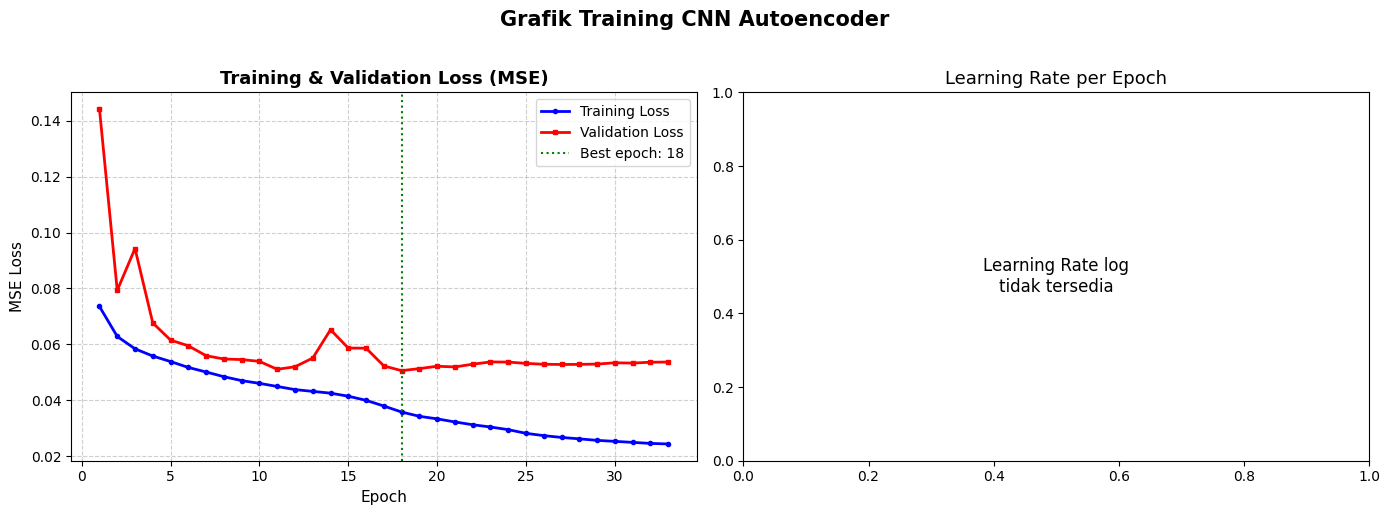

Grafik training disimpan: /content/hasil_cluster/grafik/01_training_autoencoder.png


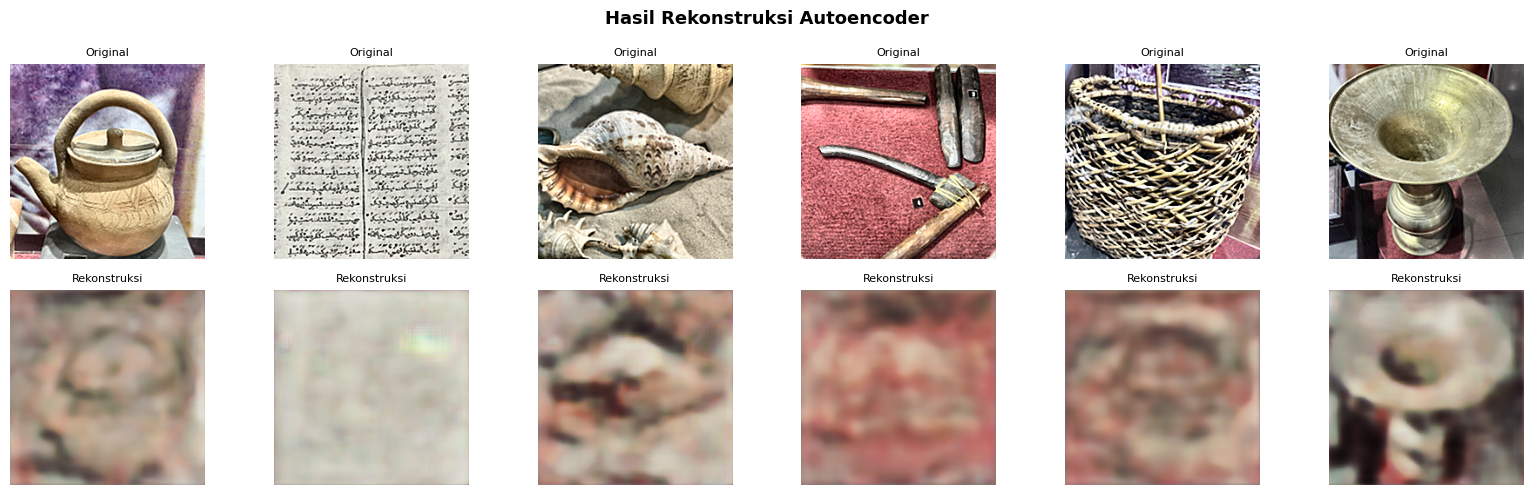

Gambar rekonstruksi disimpan: /content/hasil_cluster/grafik/02_rekonstruksi_autoencoder.png


In [41]:
# ============================================================
# CELL 7: GRAFIK TRAINING AUTOENCODER
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curve ---
ax = axes[0]
epochs_ran = range(1, len(history_ae.history['loss']) + 1)
ax.plot(epochs_ran, history_ae.history['loss'],     'b-o', markersize=3, label='Training Loss', linewidth=2)
ax.plot(epochs_ran, history_ae.history['val_loss'], 'r-s', markersize=3, label='Validation Loss', linewidth=2)
ax.set_title('Training & Validation Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MSE Loss', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
best_ep = np.argmin(history_ae.history['val_loss']) + 1
best_val = min(history_ae.history['val_loss'])
ax.axvline(best_ep, color='green', linestyle=':', linewidth=1.5, label=f'Best epoch: {best_ep}')
ax.legend(fontsize=10)

# --- Learning rate ---
ax2 = axes[1]
if 'lr' in history_ae.history:
    ax2.plot(epochs_ran, history_ae.history['lr'], 'g-^', markersize=3, linewidth=2)
    ax2.set_title('Learning Rate per Epoch', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Learning Rate', fontsize=11)
    ax2.set_yscale('log')
    ax2.grid(True, linestyle='--', alpha=0.6)
else:
    ax2.text(0.5, 0.5, 'Learning Rate log\ntidak tersedia', ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('Learning Rate per Epoch', fontsize=13)

plt.suptitle('Grafik Training CNN Autoencoder', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_path = os.path.join(CONFIG['output_root'], 'grafik', '01_training_autoencoder.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Grafik training disimpan: {save_path}')

# --- Visualisasi rekonstruksi ---
n_show = 6
sample_idx = np.random.choice(len(images), n_show, replace=False)
reconstructed = autoencoder.predict(images[sample_idx], verbose=0)

fig, axes = plt.subplots(2, n_show, figsize=(16, 5))
for i, idx in enumerate(sample_idx):
    axes[0, i].imshow(images[idx])
    axes[0, i].set_title('Original', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))
    axes[1, i].set_title('Rekonstruksi', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Hasil Rekonstruksi Autoencoder', fontsize=13, fontweight='bold')
plt.tight_layout()
save_path2 = os.path.join(CONFIG['output_root'], 'grafik', '02_rekonstruksi_autoencoder.png')
plt.savefig(save_path2, dpi=200, bbox_inches='tight')
plt.show()
print(f'Gambar rekonstruksi disimpan: {save_path2}')

## Cell 8 — Ekstraksi Latent Feature

Mengekstraksi latent features...
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
Shape latent features : (598, 64)
Min / Max             : -766.8217 / 844.6115
Mean / Std            : 4.9029 / 164.2542
Latent features disimpan ke latent_features.npy


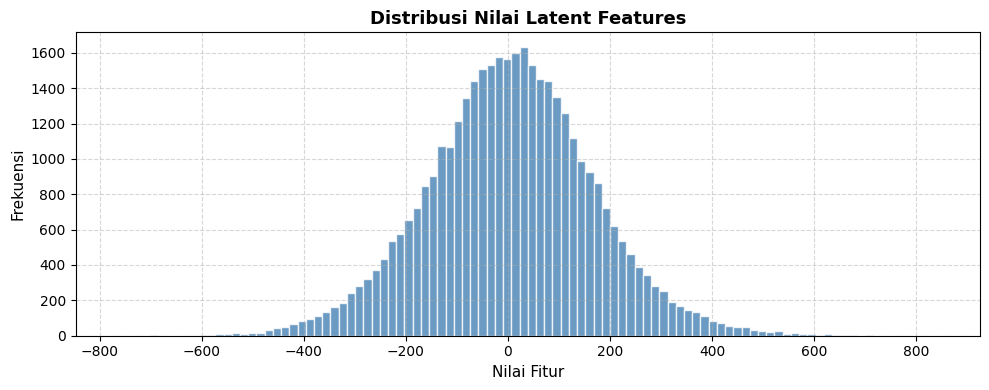

Grafik disimpan: /content/hasil_cluster/grafik/03_distribusi_latent.png


In [42]:
# ============================================================
# CELL 8: EKSTRAKSI LATENT FEATURE (REPRESENTASI TERSEMBUNYI)
# ============================================================

print('Mengekstraksi latent features...')
latent_features = encoder.predict(images, batch_size=CONFIG['ae_batch_size'], verbose=1)

print(f'Shape latent features : {latent_features.shape}')
print(f'Min / Max             : {latent_features.min():.4f} / {latent_features.max():.4f}')
print(f'Mean / Std            : {latent_features.mean():.4f} / {latent_features.std():.4f}')

# Simpan latent features
np.save(os.path.join(CONFIG['output_root'], 'latent_features.npy'), latent_features)
print('Latent features disimpan ke latent_features.npy')

# Distribusi nilai fitur
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(latent_features.flatten(), bins=100, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Distribusi Nilai Latent Features', fontsize=13, fontweight='bold')
ax.set_xlabel('Nilai Fitur', fontsize=11)
ax.set_ylabel('Frekuensi', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
save_path = os.path.join(CONFIG['output_root'], 'grafik', '03_distribusi_latent.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik disimpan: {save_path}')

## Cell 9 — K-Means 10 Cluster (Inisialisasi DEC)

Menjalankan K-Means dengan 5 cluster...

Distribusi K-Means:
  Cluster  0:   99 gambar (16.6%)
  Cluster  1:  101 gambar (16.9%)
  Cluster  2:  105 gambar (17.6%)
  Cluster  3:  135 gambar (22.6%)
  Cluster  4:  158 gambar (26.4%)

[K-Means] Silhouette Score      : 0.0893  (semakin mendekati 1 = semakin baik)
[K-Means] Davies-Bouldin Index  : 2.5483  (semakin kecil = semakin baik)
[K-Means] Calinski-Harabasz     : 52.7032  (semakin besar = semakin baik)


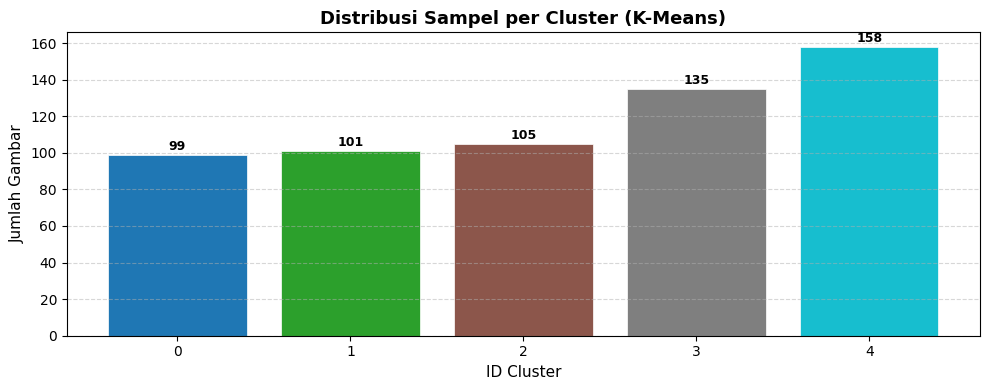

Grafik disimpan: /content/hasil_cluster/grafik/04_distribusi_kmeans.png


In [43]:
# ============================================================
# CELL 9: K-MEANS 10 CLUSTER
# Digunakan sebagai inisialisasi centroid untuk DEC
# ============================================================

print(f'Menjalankan K-Means dengan {CONFIG["n_clusters"]} cluster...')

kmeans = KMeans(
    n_clusters=CONFIG['n_clusters'],
    n_init=20,
    max_iter=500,
    random_state=SEED,
    verbose=0
)
kmeans_labels = kmeans.fit_predict(latent_features)
kmeans_centers = kmeans.cluster_centers_

# Distribusi cluster
unique, counts = np.unique(kmeans_labels, return_counts=True)
print('\nDistribusi K-Means:')
for cl, cnt in zip(unique, counts):
    print(f'  Cluster {cl:2d}: {cnt:4d} gambar ({cnt/len(kmeans_labels)*100:.1f}%)')

# Metrik evaluasi K-Means
km_sil = silhouette_score(latent_features, kmeans_labels)
km_dbi = davies_bouldin_score(latent_features, kmeans_labels)
km_chi = calinski_harabasz_score(latent_features, kmeans_labels)
print(f'\n[K-Means] Silhouette Score      : {km_sil:.4f}  (semakin mendekati 1 = semakin baik)')
print(f'[K-Means] Davies-Bouldin Index  : {km_dbi:.4f}  (semakin kecil = semakin baik)')
print(f'[K-Means] Calinski-Harabasz     : {km_chi:.4f}  (semakin besar = semakin baik)')

# Grafik distribusi cluster K-Means
fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.tab10(np.linspace(0, 1, CONFIG['n_clusters']))
bars = ax.bar(unique, counts, color=colors, edgecolor='white', linewidth=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Distribusi Sampel per Cluster (K-Means)', fontsize=13, fontweight='bold')
ax.set_xlabel('ID Cluster', fontsize=11)
ax.set_ylabel('Jumlah Gambar', fontsize=11)
ax.set_xticks(unique)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
save_path = os.path.join(CONFIG['output_root'], 'grafik', '04_distribusi_kmeans.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik disimpan: {save_path}')

## Cell 10 — Implementasi Deep Embedded Clustering (DEC)

In [44]:
# ============================================================
# CELL 10: IMPLEMENTASI DEEP EMBEDDED CLUSTERING (DEC)
# Paper: Xie et al. 2016 - "Unsupervised Deep Embedding for
#         Clustering Analysis"
# ============================================================

class ClusteringLayer(layers.Layer):
    """
    Layer clustering menggunakan distribusi Student's t.
    q_ij = (1 + ||z_i - u_j||^2 / alpha)^(-(alpha+1)/2)
           / sum_j' (1 + ||z_i - u_j'||^2 / alpha)^(-(alpha+1)/2)
    """
    def __init__(self, n_clusters, weights=None, alpha=1.0, **kwargs):
        super().__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha      = alpha
        self.init_weights = weights

    def build(self, input_shape):
        self.clusters = self.add_weight(
            shape=(self.n_clusters, input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True,
            name='cluster_centers'
        )
        if self.init_weights is not None:
            self.set_weights([self.init_weights])
        super().build(input_shape)

    def call(self, inputs):
        # Jarak ke setiap centroid
        diff     = tf.expand_dims(inputs, axis=1) - self.clusters  # (N, K, d)
        sq_dist  = tf.reduce_sum(tf.square(diff), axis=2)          # (N, K)
        numerator = tf.pow(1.0 + sq_dist / self.alpha,
                           -(self.alpha + 1.0) / 2.0)
        q = numerator / tf.reduce_sum(numerator, axis=1, keepdims=True)
        return q

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'n_clusters': self.n_clusters, 'alpha': self.alpha})
        return cfg


def build_dec_model(encoder, n_clusters, init_centers):
    """
    Model DEC = encoder + clustering layer.
    """
    dec_input    = layers.Input(shape=encoder.input_shape[1:], name='dec_input')
    encoded      = encoder(dec_input)
    cluster_out  = ClusteringLayer(n_clusters, weights=init_centers, name='clustering')(encoded)
    dec_model    = models.Model(inputs=dec_input, outputs=cluster_out, name='DEC')
    return dec_model


def target_distribution(q):
    """
    Hitung distribusi target P dari soft assignment Q.
    p_ij = (q_ij^2 / f_j) / sum_j' (q_ij'^2 / f_j')
    f_j = sum_i q_ij (frekuensi cluster)
    """
    weight = q ** 2 / q.sum(axis=0)
    p = weight / weight.sum(axis=1, keepdims=True)
    return p


# Bangun model DEC
dec_model = build_dec_model(encoder, CONFIG['n_clusters'], kmeans_centers)
dec_model.compile(
    optimizer=Adam(learning_rate=CONFIG['dec_lr']),
    loss='kld'                          # Kullback-Leibler divergence
)

print('=== Arsitektur Model DEC ===')
dec_model.summary()
print(f'\nCentroid diinisialisasi dari K-Means ({CONFIG["n_clusters"]} cluster).')

=== Arsitektur Model DEC ===


Model: "DEC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dec_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 64)             │    26,113,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clustering (ClusteringLayer)    │ (None, 5)              │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,114,112 (99.62 MB)

 Trainable params: 26,113,152 (99.61 MB)

 Non-trainable params: 960 (3.75 KB)


Centroid diinisialisasi dari K-Means (5 cluster).


## Cell 11 — Training DEC: Update Centroid Iteratif + Stopping Criterion

In [45]:
# ============================================================
# CELL 11: TRAINING DEC
# - Update centroid iteratif setiap `update_interval` batch
# - Stopping criterion: delta label < tol
# ============================================================

print('Mulai training DEC...')
print(f'Update centroid setiap : {CONFIG["update_interval"]} iterasi')
print(f'Stopping criterion tol : {CONFIG["tol"]}')
print('-' * 50)

loss_history_dec  = []
delta_label_hist  = []
label_prev        = None
best_dec_loss     = np.inf
best_dec_labels   = None
n_samples         = images.shape[0]
batch_size_dec    = CONFIG['dec_batch_size']
n_batches         = int(np.ceil(n_samples / batch_size_dec))

for epoch in range(1, CONFIG['dec_epochs'] + 1):
    epoch_loss = 0.0

    # Hitung Q dan P di awal setiap epoch
    q = dec_model.predict(images, batch_size=batch_size_dec, verbose=0)
    p = target_distribution(q)

    # Label saat ini
    label_curr = q.argmax(axis=1)

    # Hitung delta label (proporsi label yang berubah)
    if label_prev is not None:
        delta = np.sum(label_curr != label_prev) / n_samples
        delta_label_hist.append(delta)
    else:
        delta = 1.0
        delta_label_hist.append(1.0)

    # Stopping criterion
    if epoch > 1 and delta < CONFIG['tol']:
        print(f'[Epoch {epoch:3d}] STOP: delta label ({delta:.5f}) < tol ({CONFIG["tol"]})')
        break

    label_prev = label_curr.copy()

    # Update centroid setiap update_interval epoch
    if epoch % CONFIG['update_interval'] == 0 or epoch == 1:
        # Train satu epoch dengan target distribusi P
        hist = dec_model.fit(
            images, p,
            batch_size=batch_size_dec,
            epochs=1,
            verbose=0
        )
        epoch_loss = hist.history['loss'][0]
    else:
        hist = dec_model.fit(
            images, p,
            batch_size=batch_size_dec,
            epochs=1,
            verbose=0
        )
        epoch_loss = hist.history['loss'][0]

    loss_history_dec.append(epoch_loss)

    # Simpan model terbaik
    if epoch_loss < best_dec_loss:
        best_dec_loss   = epoch_loss
        best_dec_labels = label_curr.copy()
        dec_model.save(os.path.join(CONFIG['output_root'], 'model', 'dec_best.keras'))

    if epoch % 10 == 0 or epoch == 1:
        uniq, cnts = np.unique(label_curr, return_counts=True)
        dist_str = ', '.join([f'C{u}:{c}' for u, c in zip(uniq, cnts)])
        print(f'[Epoch {epoch:3d}] Loss={epoch_loss:.6f} | Delta={delta:.5f} | {dist_str}')

# Ambil label final
q_final      = dec_model.predict(images, batch_size=batch_size_dec, verbose=0)
dec_labels   = q_final.argmax(axis=1)

np.save(os.path.join(CONFIG['output_root'], 'dec_labels.npy'), dec_labels)
np.save(os.path.join(CONFIG['output_root'], 'q_final.npy'), q_final)
print(f'\nDEC selesai. Label disimpan.')
print(f'Loss terbaik   : {best_dec_loss:.6f}')
print(f'Label final shape: {dec_labels.shape}')

Mulai training DEC...
Update centroid setiap : 5 iterasi
Stopping criterion tol : 0.001
--------------------------------------------------
[Epoch   1] Loss=0.099323 | Delta=1.00000 | C0:99, C1:101, C2:105, C3:135, C4:158
[Epoch  10] Loss=0.153239 | Delta=0.02174 | C0:80, C1:83, C2:188, C3:103, C4:144
[Epoch  20] Loss=0.203072 | Delta=0.05853 | C0:109, C1:37, C2:196, C3:136, C4:120
[Epoch  30] Loss=0.112168 | Delta=0.19565 | C0:102, C1:39, C2:262, C3:120, C4:75
[Epoch  40] Loss=0.096356 | Delta=0.01171 | C0:44, C2:337, C3:53, C4:164
[Epoch  50] Loss=0.102253 | Delta=0.00167 | C0:29, C2:344, C3:59, C4:166
[Epoch  55] STOP: delta label (0.00000) < tol (0.001)

DEC selesai. Label disimpan.
Loss terbaik   : 0.089286
Label final shape: (598,)


## Cell 12 — Grafik Training DEC (untuk Skripsi/Paper)

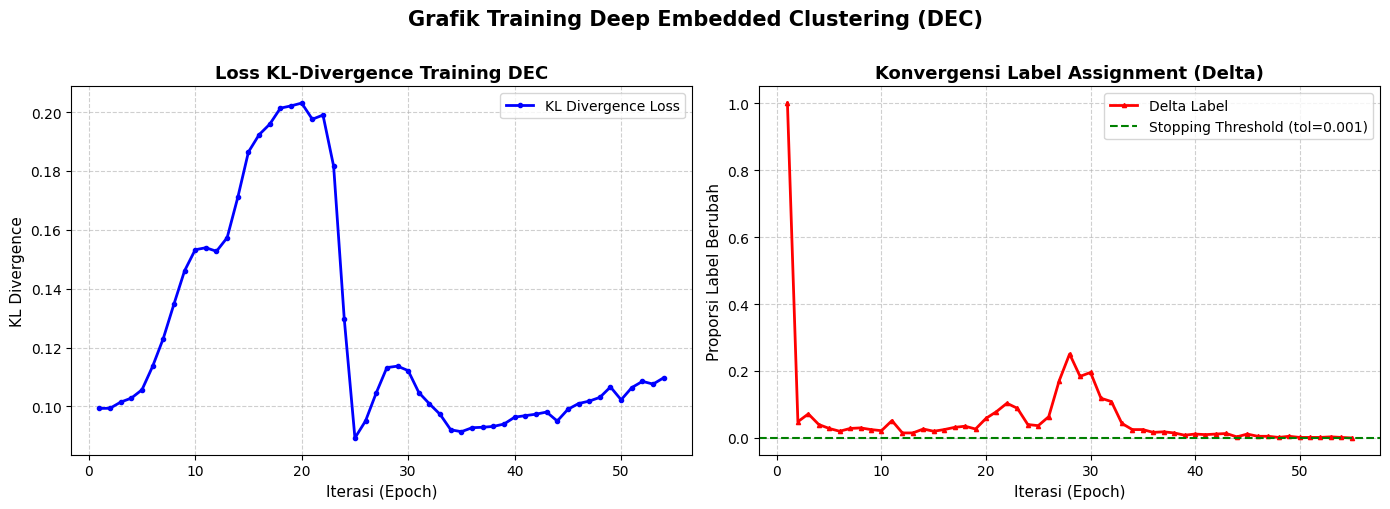

Grafik DEC disimpan: /content/hasil_cluster/grafik/05_training_dec.png


In [46]:
# ============================================================
# CELL 12: GRAFIK TRAINING DEC
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- KL Loss ---
ax = axes[0]
ax.plot(range(1, len(loss_history_dec)+1), loss_history_dec,
        'b-o', markersize=3, linewidth=2, label='KL Divergence Loss')
ax.set_title('Loss KL-Divergence Training DEC', fontsize=13, fontweight='bold')
ax.set_xlabel('Iterasi (Epoch)', fontsize=11)
ax.set_ylabel('KL Divergence', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=10)

# --- Delta Label ---
ax2 = axes[1]
ax2.plot(range(1, len(delta_label_hist)+1), delta_label_hist,
         'r-^', markersize=3, linewidth=2, label='Delta Label')
ax2.axhline(CONFIG['tol'], color='green', linestyle='--',
            linewidth=1.5, label=f"Stopping Threshold (tol={CONFIG['tol']})")
ax2.set_title('Konvergensi Label Assignment (Delta)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Iterasi (Epoch)', fontsize=11)
ax2.set_ylabel('Proporsi Label Berubah', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=10)

plt.suptitle('Grafik Training Deep Embedded Clustering (DEC)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(CONFIG['output_root'], 'grafik', '05_training_dec.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Grafik DEC disimpan: {save_path}')

## Cell 13 — Evaluasi Clustering (Silhouette, DBI, CHI)


=== Evaluasi: K-Means ===
  Silhouette Score      : 0.0893  (optimal → 1.0)
  Davies-Bouldin Index  : 2.5483  (optimal → 0.0)
  Calinski-Harabasz     : 52.7032  (semakin besar semakin baik)

=== Evaluasi: DEC ===
  Silhouette Score      : 0.0481  (optimal → 1.0)
  Davies-Bouldin Index  : 3.4571  (optimal → 0.0)
  Calinski-Harabasz     : 34.9774  (semakin besar semakin baik)

Hasil evaluasi disimpan ke:
/content/hasil_cluster/evaluasi_clustering.json


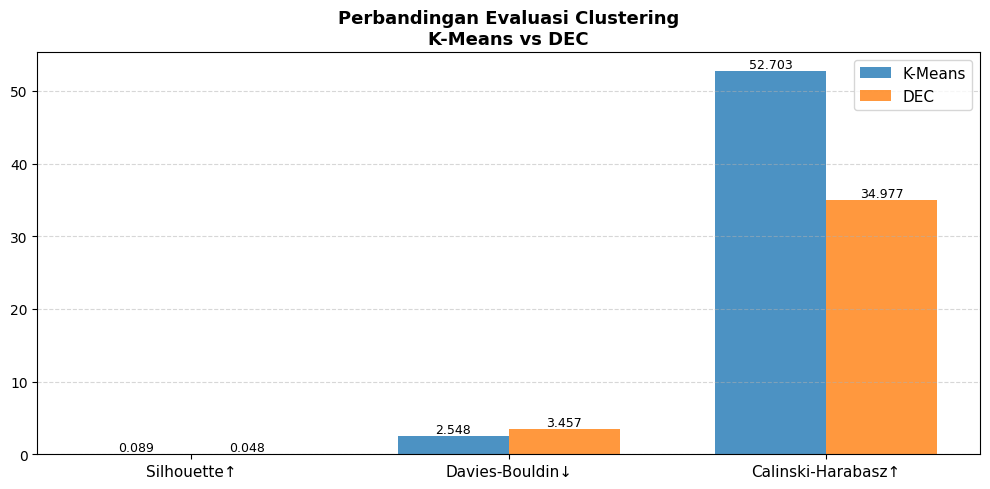

Grafik evaluasi disimpan:
/content/hasil_cluster/grafik/06_evaluasi_clustering.png


In [47]:
# ============================================================
# CELL 13: EVALUASI CLUSTERING (FIX JSON SERIALIZATION)
# ============================================================

def evaluate_clustering(features, labels, method_name):

    sil = silhouette_score(features, labels)
    dbi = davies_bouldin_score(features, labels)
    chi = calinski_harabasz_score(features, labels)

    print(f'\n=== Evaluasi: {method_name} ===')
    print(f'  Silhouette Score      : {sil:.4f}  (optimal → 1.0)')
    print(f'  Davies-Bouldin Index  : {dbi:.4f}  (optimal → 0.0)')
    print(f'  Calinski-Harabasz     : {chi:.4f}  (semakin besar semakin baik)')

    return {
        'method': method_name,
        'silhouette': float(round(sil, 4)),
        'davies_bouldin': float(round(dbi, 4)),
        'calinski_harabasz': float(round(chi, 4))
    }


# ============================================================
# Evaluasi
# ============================================================

result_km = evaluate_clustering(
    latent_features,
    kmeans_labels,
    'K-Means'
)

result_dec = evaluate_clustering(
    latent_features,
    dec_labels,
    'DEC'
)

# ============================================================
# Simpan JSON
# ============================================================

eval_results = [result_km, result_dec]

json_path = os.path.join(
    CONFIG['output_root'],
    'evaluasi_clustering.json'
)

with open(json_path, 'w') as f:
    json.dump(
        eval_results,
        f,
        indent=2
    )

print(
    f'\nHasil evaluasi disimpan ke:\n{json_path}'
)

# ============================================================
# Grafik Perbandingan
# ============================================================

metrics = [
    'silhouette',
    'davies_bouldin',
    'calinski_harabasz'
]

metric_labels = [
    'Silhouette↑',
    'Davies-Bouldin↓',
    'Calinski-Harabasz↑'
]

km_vals = [result_km[m] for m in metrics]
dec_vals = [result_dec[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(
    figsize=(10, 5)
)

bars1 = ax.bar(
    x - width/2,
    km_vals,
    width,
    label='K-Means',
    alpha=0.8
)

bars2 = ax.bar(
    x + width/2,
    dec_vals,
    width,
    label='DEC',
    alpha=0.8
)

for bar in list(bars1) + list(bars2):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(
    metric_labels,
    fontsize=11
)

ax.set_title(
    'Perbandingan Evaluasi Clustering\nK-Means vs DEC',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=11)

ax.grid(
    True,
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

save_path = os.path.join(
    CONFIG['output_root'],
    'grafik',
    '06_evaluasi_clustering.png'
)

plt.savefig(
    save_path,
    dpi=200,
    bbox_inches='tight'
)

plt.show()

print(
    f'Grafik evaluasi disimpan:\n{save_path}'
)

## Cell 14 — Visualisasi t-SNE

Menjalankan t-SNE (mungkin beberapa menit)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 598 samples in 0.002s...
[t-SNE] Computed neighbors for 598 samples in 0.053s...
[t-SNE] Computed conditional probabilities for sample 598 / 598
[t-SNE] Mean sigma: 435.381637


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.656971
[t-SNE] KL divergence after 1000 iterations: 1.111808
t-SNE selesai. Shape: (598, 2)


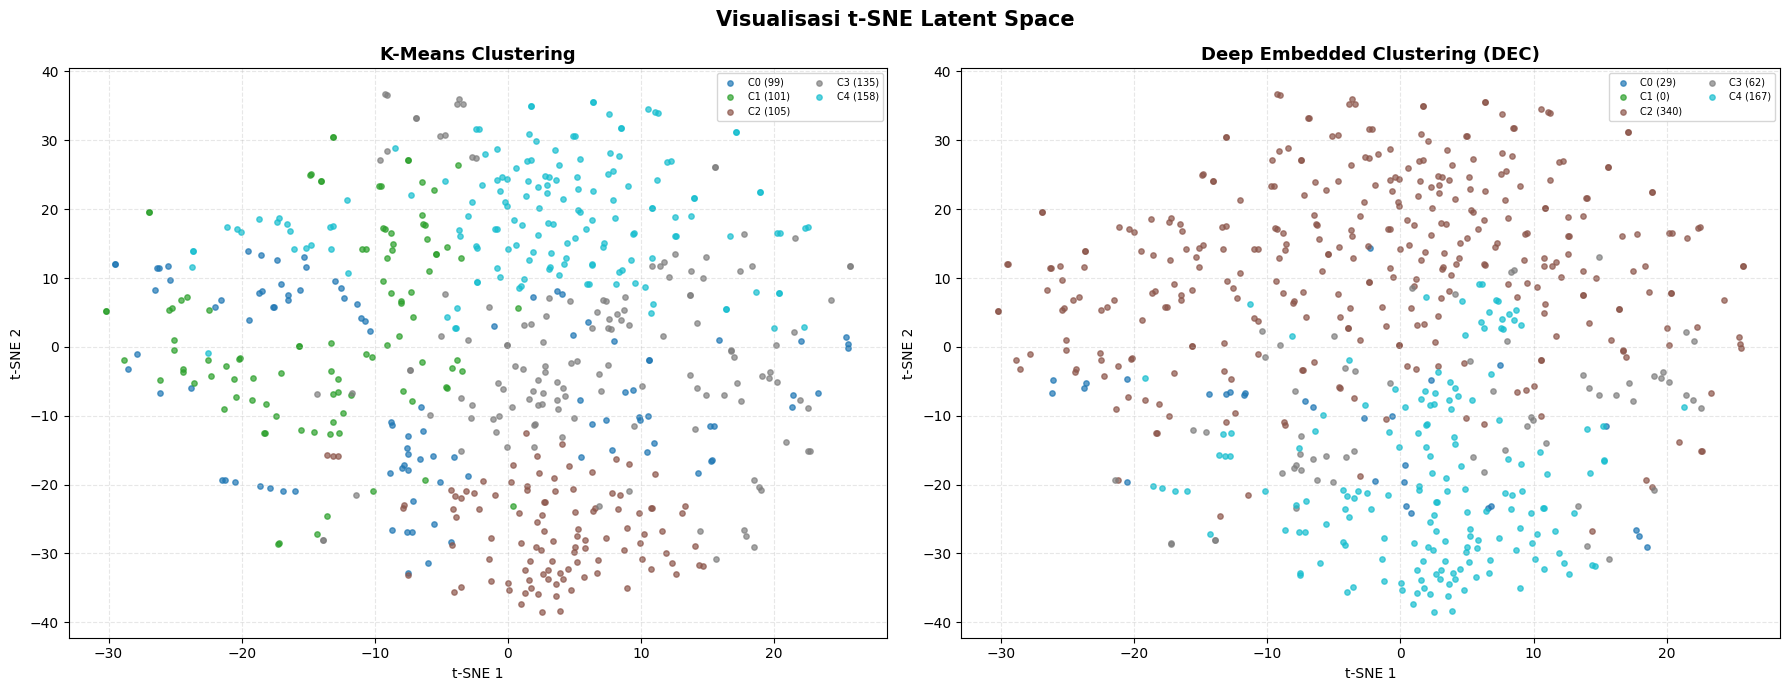

Grafik t-SNE disimpan: /content/hasil_cluster/grafik/07_tsne.png


In [48]:
# ============================================================
# CELL 14: VISUALISASI t-SNE
# Reduksi dimensi latent feature ke 2D menggunakan t-SNE
# ============================================================

print('Menjalankan t-SNE (mungkin beberapa menit)...')
# Gunakan PCA dulu untuk mempercepat t-SNE
pca_50 = PCA(n_components=min(50, latent_features.shape[1]), random_state=SEED)
feat_pca50 = pca_50.fit_transform(latent_features)

tsne = TSNE(
    n_components=2,
    perplexity=CONFIG['tsne_perplexity'],
    n_iter=1000,
    random_state=SEED,
    verbose=1
)
feat_2d = tsne.fit_transform(feat_pca50)
np.save(os.path.join(CONFIG['output_root'], 'tsne_2d.npy'), feat_2d)
print(f't-SNE selesai. Shape: {feat_2d.shape}')

# --- Plot t-SNE side by side: K-Means vs DEC ---
colors_map = plt.cm.tab10(np.linspace(0, 1, CONFIG['n_clusters']))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
titles  = ['K-Means Clustering', 'Deep Embedded Clustering (DEC)']
all_lbl = [kmeans_labels, dec_labels]

for ax, lbl, title in zip(axes, all_lbl, titles):
    for cl in range(CONFIG['n_clusters']):
        mask = lbl == cl
        ax.scatter(
            feat_2d[mask, 0], feat_2d[mask, 1],
            s=15, alpha=0.7,
            color=colors_map[cl],
            label=f'C{cl} ({mask.sum()})'
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Visualisasi t-SNE Latent Space', fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(CONFIG['output_root'], 'grafik', '07_tsne.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Grafik t-SNE disimpan: {save_path}')

## Cell 15 — Visualisasi PCA

Variance explained: PC1=18.5%, PC2=8.9%


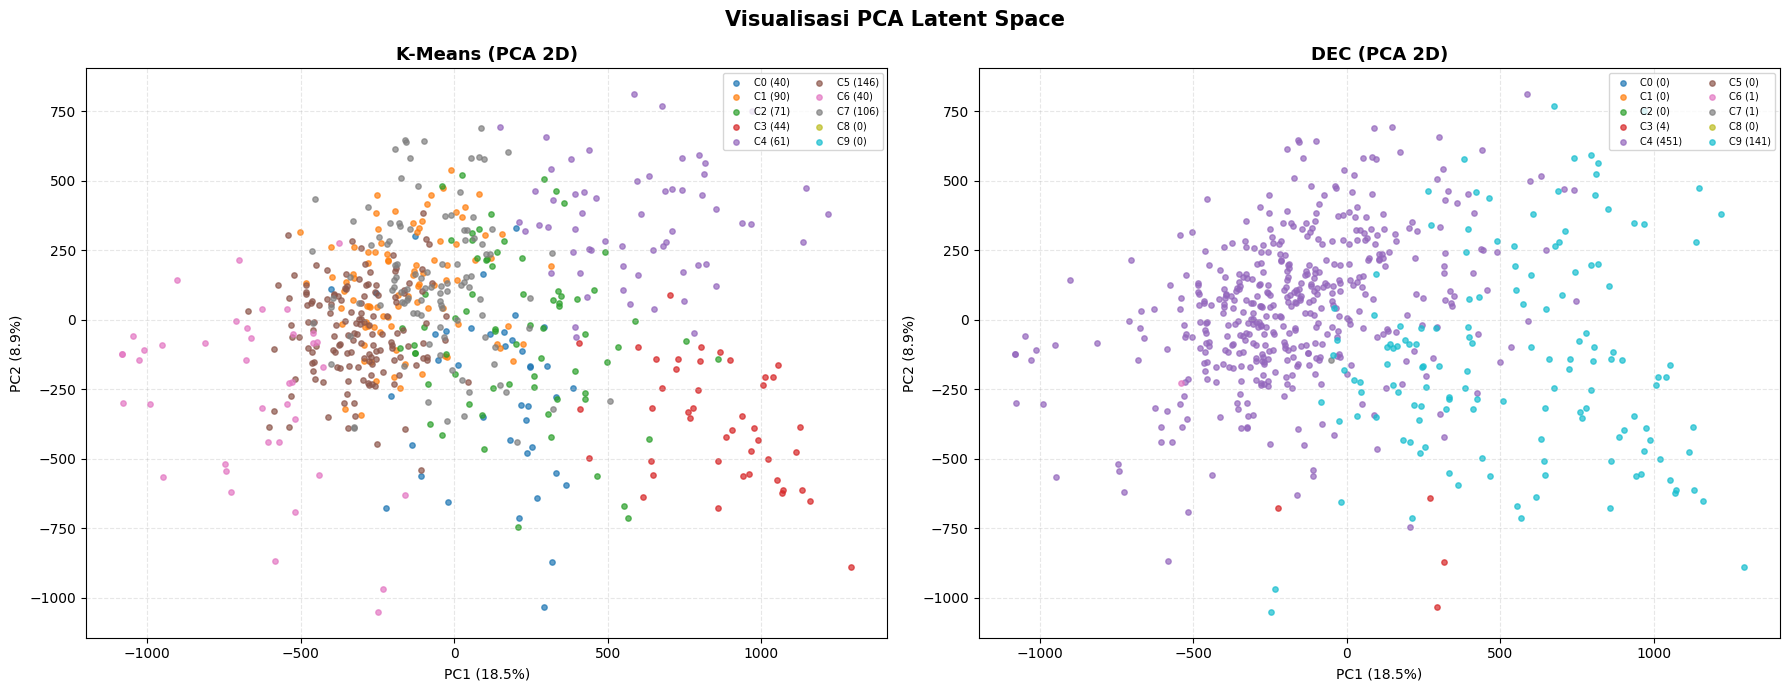

Grafik PCA disimpan: /content/hasil_cluster/grafik/08_pca.png


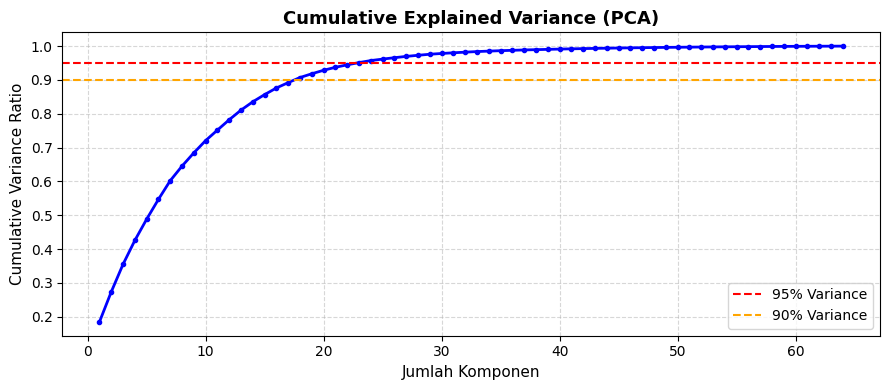

Scree plot disimpan: /content/hasil_cluster/grafik/09_scree_plot.png


In [35]:
# ============================================================
# CELL 15: VISUALISASI PCA
# ============================================================

pca_2d = PCA(n_components=2, random_state=SEED)
feat_pca2 = pca_2d.fit_transform(latent_features)
var_exp = pca_2d.explained_variance_ratio_
print(f'Variance explained: PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
titles  = ['K-Means (PCA 2D)', 'DEC (PCA 2D)']
all_lbl = [kmeans_labels, dec_labels]

for ax, lbl, title in zip(axes, all_lbl, titles):
    for cl in range(CONFIG['n_clusters']):
        mask = lbl == cl
        ax.scatter(
            feat_pca2[mask, 0], feat_pca2[mask, 1],
            s=15, alpha=0.7,
            color=colors_map[cl],
            label=f'C{cl} ({mask.sum()})'
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=10)
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Visualisasi PCA Latent Space', fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(CONFIG['output_root'], 'grafik', '08_pca.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Grafik PCA disimpan: {save_path}')

# --- Explained variance (scree plot) ---
pca_full = PCA(random_state=SEED).fit(latent_features)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, 'b-o', markersize=3, linewidth=2)
ax.axhline(0.95, color='red', linestyle='--', label='95% Variance')
ax.axhline(0.90, color='orange', linestyle='--', label='90% Variance')
ax.set_title('Cumulative Explained Variance (PCA)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Komponen', fontsize=11)
ax.set_ylabel('Cumulative Variance Ratio', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
save_path2 = os.path.join(CONFIG['output_root'], 'grafik', '09_scree_plot.png')
plt.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Scree plot disimpan: {save_path2}')

## Cell 16 — Contoh Citra per Cluster

Gambar disimpan: /content/hasil_cluster/grafik/10_contoh_citra_cluster_dec.png


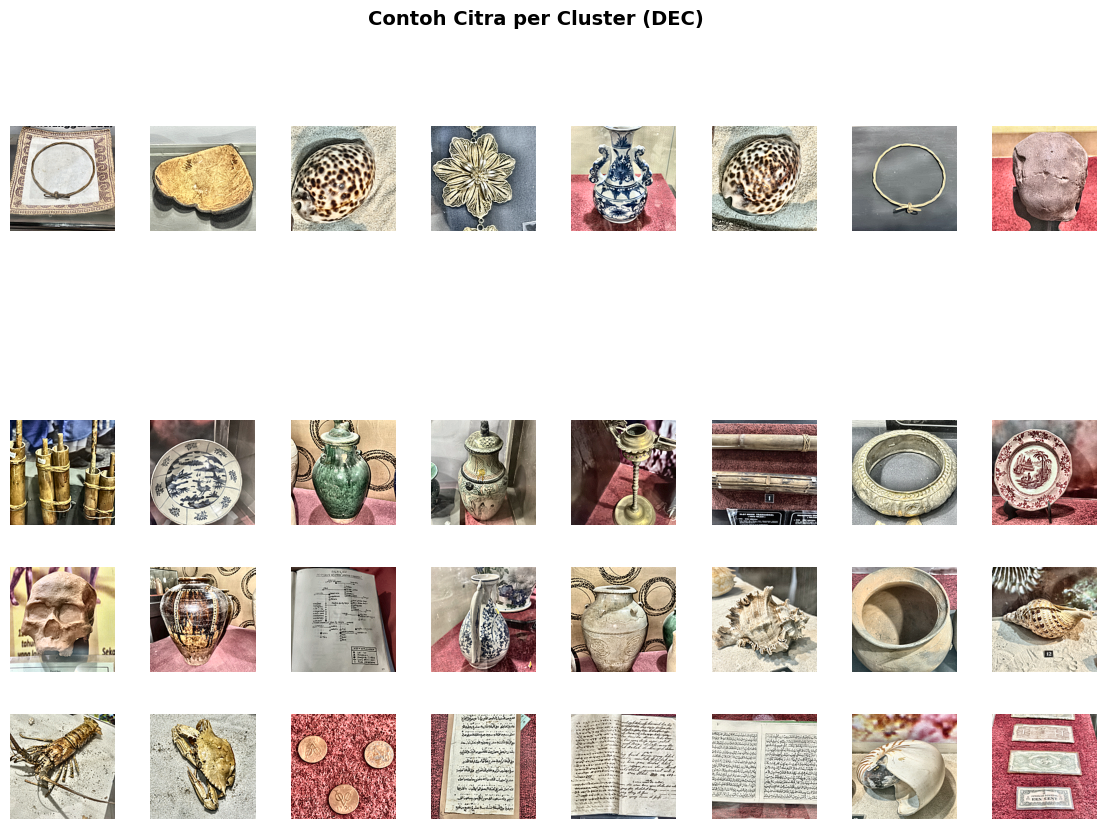

Gambar disimpan: /content/hasil_cluster/grafik/11_contoh_citra_cluster_kmeans.png


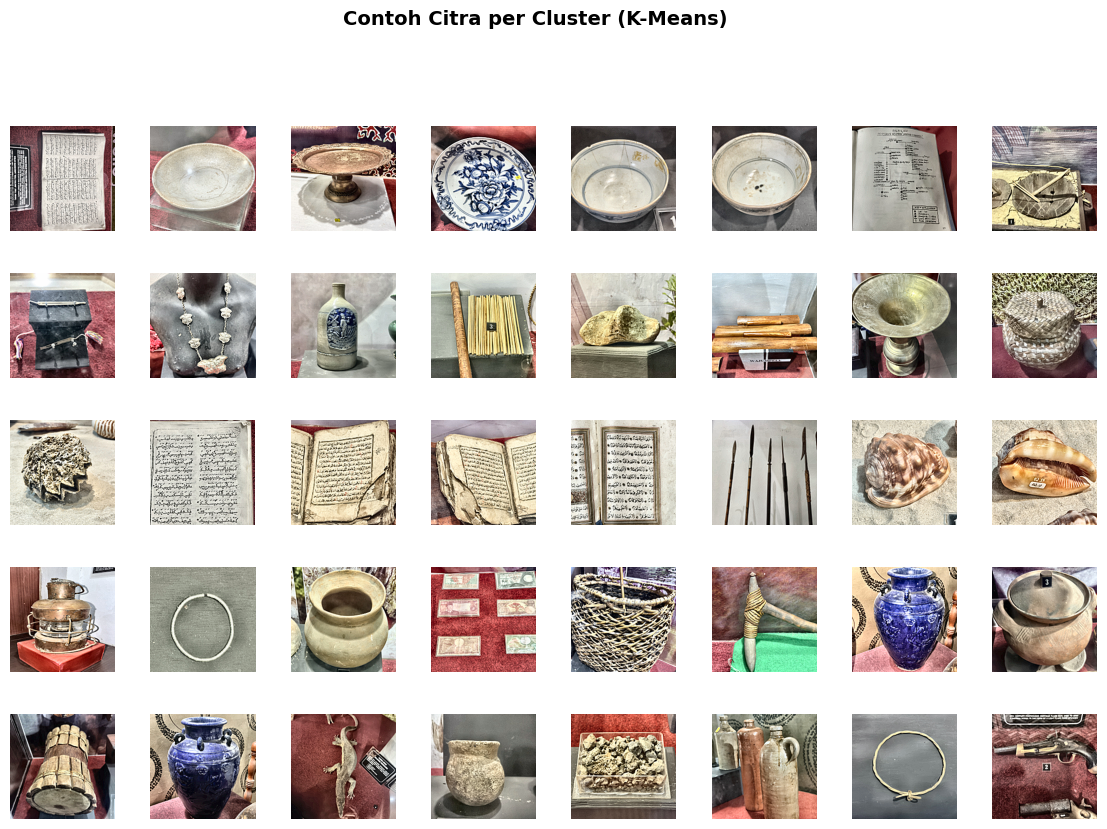

In [49]:
# ============================================================
# CELL 16: VISUALISASI CONTOH CITRA PER CLUSTER
# Tampilkan N sampel gambar dari setiap cluster DEC
# ============================================================

def plot_cluster_samples(images, labels, n_clusters, n_sample=8, title='DEC', save_path=None):
    """
    Grid: baris = cluster, kolom = sampel citra.
    """
    fig = plt.figure(figsize=(n_sample * 1.8, n_clusters * 1.8))
    gs  = gridspec.GridSpec(n_clusters, n_sample, figure=fig,
                             hspace=0.4, wspace=0.05)

    for cl in range(n_clusters):
        idx_cl = np.where(labels == cl)[0]
        if len(idx_cl) == 0:
            continue
        chosen = np.random.choice(idx_cl, min(n_sample, len(idx_cl)), replace=False)
        for j, img_idx in enumerate(chosen):
            ax = fig.add_subplot(gs[cl, j])
            ax.imshow(images[img_idx])
            ax.axis('off')
            if j == 0:
                ax.set_ylabel(f'C{cl}\n({len(idx_cl)})', fontsize=8,
                              rotation=0, labelpad=30, va='center')

    fig.suptitle(f'Contoh Citra per Cluster ({title})', fontsize=14, fontweight='bold', y=1.01)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Gambar disimpan: {save_path}')
    plt.show()


plot_cluster_samples(
    images, dec_labels,
    CONFIG['n_clusters'],
    n_sample=CONFIG['n_sample_vis'],
    title='DEC',
    save_path=os.path.join(CONFIG['output_root'], 'grafik', '10_contoh_citra_cluster_dec.png')
)

plot_cluster_samples(
    images, kmeans_labels,
    CONFIG['n_clusters'],
    n_sample=CONFIG['n_sample_vis'],
    title='K-Means',
    save_path=os.path.join(CONFIG['output_root'], 'grafik', '11_contoh_citra_cluster_kmeans.png')
)

## Cell 17 — Penyimpanan Hasil Cluster ke Folder Otomatis

In [50]:
# ============================================================
# CELL 17: PENYIMPANAN HASIL CLUSTER KE FOLDER OTOMATIS
# Struktur:
#   hasil_cluster/
#     cluster_dec/
#       cluster_00/ → gambar cluster 0
#       cluster_01/ → gambar cluster 1
#       ...
#     cluster_kmeans/
#       cluster_00/
#       ...
# ============================================================

def save_clusters_to_folders(image_paths, labels, n_clusters, output_dir, method_name='dec'):
    """
    Salin setiap gambar ke folder cluster yang sesuai.
    Juga buat file manifest CSV.
    """
    base_dir = os.path.join(output_dir, f'cluster_{method_name}')

    # Buat folder cluster
    for cl in range(n_clusters):
        os.makedirs(os.path.join(base_dir, f'cluster_{cl:02d}'), exist_ok=True)

    manifest = []
    for path, label in tqdm(zip(image_paths, labels),
                            total=len(image_paths),
                            desc=f'Menyimpan ({method_name})'):
        fname    = os.path.basename(path)
        dest_dir = os.path.join(base_dir, f'cluster_{label:02d}')
        dest     = os.path.join(dest_dir, fname)

        # Hindari konflik nama
        if os.path.exists(dest):
            name, ext = os.path.splitext(fname)
            dest = os.path.join(dest_dir, f'{name}_{np.random.randint(1000,9999)}{ext}')

        shutil.copy2(path, dest)
        manifest.append({'original_path': path, 'cluster': int(label), 'saved_to': dest})

    # Simpan manifest ke CSV
    import csv
    manifest_path = os.path.join(output_dir, f'manifest_{method_name}.csv')
    with open(manifest_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['original_path', 'cluster', 'saved_to'])
        writer.writeheader()
        writer.writerows(manifest)

    # Ringkasan
    print(f'\n[{method_name.upper()}] Penyimpanan selesai → {base_dir}')
    for cl in range(n_clusters):
        n_in_cl = sum(1 for m in manifest if m['cluster'] == cl)
        print(f'  cluster_{cl:02d}: {n_in_cl} gambar')
    print(f'Manifest: {manifest_path}')
    return manifest


# Simpan hasil DEC
manifest_dec = save_clusters_to_folders(
    image_paths, dec_labels,
    CONFIG['n_clusters'],
    CONFIG['output_root'],
    method_name='dec'
)

# Simpan hasil K-Means
manifest_km = save_clusters_to_folders(
    image_paths, kmeans_labels,
    CONFIG['n_clusters'],
    CONFIG['output_root'],
    method_name='kmeans'
)

Menyimpan (dec): 100%|██████████| 598/598 [00:38<00:00, 15.53it/s]



[DEC] Penyimpanan selesai → /content/hasil_cluster/cluster_dec
  cluster_00: 29 gambar
  cluster_01: 0 gambar
  cluster_02: 340 gambar
  cluster_03: 62 gambar
  cluster_04: 167 gambar
Manifest: /content/hasil_cluster/manifest_dec.csv


Menyimpan (kmeans): 100%|██████████| 598/598 [00:55<00:00, 10.83it/s]


[KMEANS] Penyimpanan selesai → /content/hasil_cluster/cluster_kmeans
  cluster_00: 99 gambar
  cluster_01: 101 gambar
  cluster_02: 105 gambar
  cluster_03: 135 gambar
  cluster_04: 158 gambar
Manifest: /content/hasil_cluster/manifest_kmeans.csv


## Cell 18 — Grafik Distribusi Final & Ringkasan Lengkap

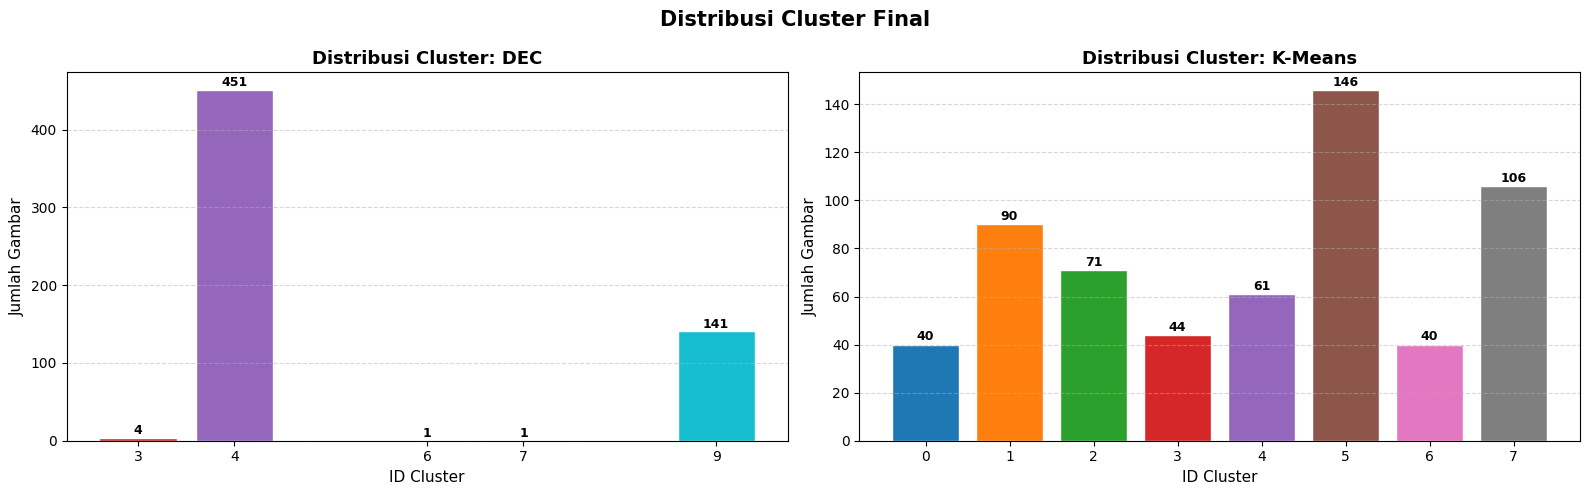

Disimpan: /content/hasil_cluster/grafik/12_distribusi_final.png


/tmp/ipykernel_15573/431452605.py:34: RuntimeWarning: Mean of empty slice.
  mean_q = np.array([q_final[dec_labels == cl].mean(axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


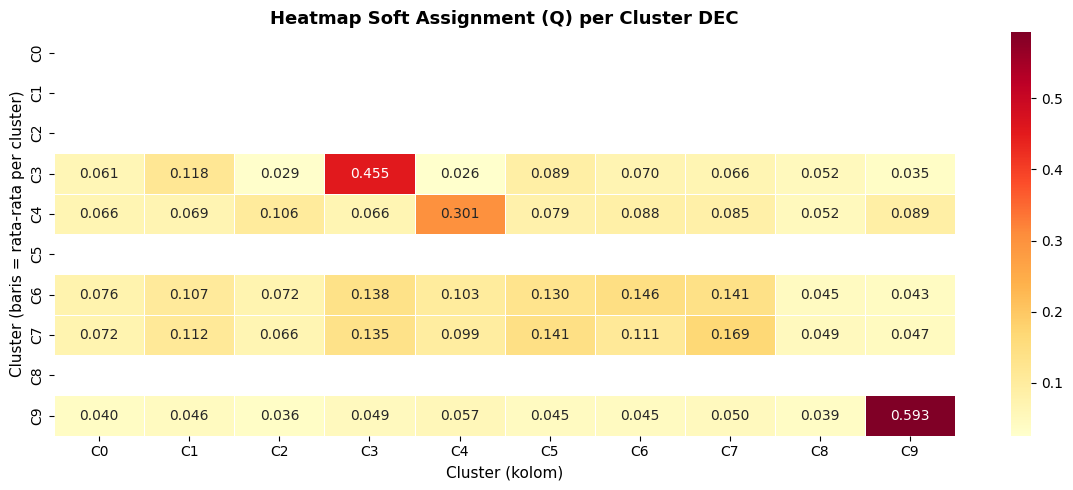

Disimpan: /content/hasil_cluster/grafik/13_heatmap_soft_assignment.png

RINGKASAN HASIL AKHIR
Dataset         : 598 gambar, shape (598, 224, 224, 3)
Latent dim      : 64
Jumlah cluster  : 10
AE epochs ran   : 36
DEC epochs ran  : 49

Metrik                       K-Means        DEC
-----------------------------------------------
Silhouette Score              0.0599     0.1323
Davies-Bouldin Index          2.4959     1.4988
Calinski-Harabasz               35.8       20.6
Semua output tersimpan di: /content/hasil_cluster
Ringkasan disimpan: /content/hasil_cluster/ringkasan_hasil.txt


In [37]:
# ============================================================
# CELL 18: GRAFIK DISTRIBUSI FINAL & RINGKASAN HASIL
# ============================================================

# --- Distribusi DEC final ---
uniq_dec, cnts_dec = np.unique(dec_labels, return_counts=True)
uniq_km,  cnts_km  = np.unique(kmeans_labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, uniq, cnts, title, color in [
    (axes[0], uniq_dec, cnts_dec, 'DEC', 'darkorange'),
    (axes[1], uniq_km,  cnts_km,  'K-Means', 'steelblue')
]:
    cmap = plt.cm.tab10(np.linspace(0, 1, CONFIG['n_clusters']))
    bars = ax.bar(uniq, cnts, color=[cmap[i] for i in uniq], edgecolor='white')
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'Distribusi Cluster: {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('ID Cluster', fontsize=11)
    ax.set_ylabel('Jumlah Gambar', fontsize=11)
    ax.set_xticks(uniq)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Distribusi Cluster Final', fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(CONFIG['output_root'], 'grafik', '12_distribusi_final.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Disimpan: {save_path}')

# --- Heatmap Soft Assignment (Confidence) ---
mean_q = np.array([q_final[dec_labels == cl].mean(axis=0)
                   for cl in range(CONFIG['n_clusters'])])

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(mean_q, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=[f'C{i}' for i in range(CONFIG['n_clusters'])],
            yticklabels=[f'C{i}' for i in range(CONFIG['n_clusters'])],
            ax=ax, linewidths=0.5)
ax.set_title('Heatmap Soft Assignment (Q) per Cluster DEC', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster (kolom)', fontsize=11)
ax.set_ylabel('Cluster (baris = rata-rata per cluster)', fontsize=11)
plt.tight_layout()
save_path2 = os.path.join(CONFIG['output_root'], 'grafik', '13_heatmap_soft_assignment.png')
plt.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Disimpan: {save_path2}')

# --- Cetak ringkasan lengkap ---
print('\n' + '='*60)
print('RINGKASAN HASIL AKHIR')
print('='*60)
print(f'Dataset         : {len(images)} gambar, shape {images.shape}')
print(f'Latent dim      : {CONFIG["latent_dim"]}')
print(f'Jumlah cluster  : {CONFIG["n_clusters"]}')
print(f'AE epochs ran   : {len(history_ae.history["loss"])}')
print(f'DEC epochs ran  : {len(loss_history_dec)}')
print()
print(f"{'Metrik':<25} {'K-Means':>10} {'DEC':>10}")
print('-'*47)
print(f"{'Silhouette Score':<25} {result_km['silhouette']:>10.4f} {result_dec['silhouette']:>10.4f}")
print(f"{'Davies-Bouldin Index':<25} {result_km['davies_bouldin']:>10.4f} {result_dec['davies_bouldin']:>10.4f}")
print(f"{'Calinski-Harabasz':<25} {result_km['calinski_harabasz']:>10.1f} {result_dec['calinski_harabasz']:>10.1f}")
print('='*60)
print(f'Semua output tersimpan di: {CONFIG["output_root"]}')
print('='*60)

# Simpan ringkasan ke txt
summary_path = os.path.join(CONFIG['output_root'], 'ringkasan_hasil.txt')
with open(summary_path, 'w') as f:
    f.write('RINGKASAN HASIL DEC CLUSTERING\n')
    f.write('='*60 + '\n')
    f.write(f'Dataset         : {len(images)} gambar\n')
    f.write(f'Latent dim      : {CONFIG["latent_dim"]}\n')
    f.write(f'Jumlah cluster  : {CONFIG["n_clusters"]}\n')
    f.write(f'AE epochs ran   : {len(history_ae.history["loss"])}\n')
    f.write(f'DEC epochs ran  : {len(loss_history_dec)}\n\n')
    f.write(f"{'Metrik':<25} {'K-Means':>10} {'DEC':>10}\n")
    f.write('-'*47 + '\n')
    f.write(f"{'Silhouette Score':<25} {result_km['silhouette']:>10.4f} {result_dec['silhouette']:>10.4f}\n")
    f.write(f"{'Davies-Bouldin Index':<25} {result_km['davies_bouldin']:>10.4f} {result_dec['davies_bouldin']:>10.4f}\n")
    f.write(f"{'Calinski-Harabasz':<25} {result_km['calinski_harabasz']:>10.1f} {result_dec['calinski_harabasz']:>10.1f}\n")
print(f'Ringkasan disimpan: {summary_path}')

## Cell 19 — Download Semua Hasil (Google Colab)

In [ ]:
# ============================================================
# CELL 19: ZIP & DOWNLOAD SEMUA HASIL (GOOGLE COLAB)
# ============================================================

from google.colab import files

# Zip seluruh folder output
zip_name = '/content/hasil_dec_clustering.zip'
shutil.make_archive(
    base_name='/content/hasil_dec_clustering',
    format='zip',
    root_dir=CONFIG['output_root']
)
print(f'File zip dibuat: {zip_name}')

# Download otomatis
files.download(zip_name)
print('Download dimulai...')